# ISLES 2026 — Exploratory Data Analysis
**Read-only.** No files are written except `eda_summary.json` at the end.

### What this notebook produces
| Section | Purpose | Feeds into |
|---|---|---|
| 1. Metadata audit | Chronicity / days / site distributions | CV split strategy |
| 2. Orientation audit | Axes, voxel spacing, affine sanity | Preprocessing |
| 3. Intensity audit | Per-scan histogram stats | Normalisation choice |
| 4. Lesion audit | Volume, prevalence, size stratification | Loss weighting, augmentation |
| 5. Site heterogeneity | Cross-site intensity + spacing variance | Harmonisation decision |
| 6. Summary export | `eda_summary.json` for pipeline config | `config.yaml` |

**Dataset mount path:** `/kaggle/input/atlas-raw/`

In [1]:
import os
import subprocess
from pathlib import Path

# 1. Mount path to the input archive from Notebook A
ARCHIVE_PATH = Path(
    "/kaggle/input/notebooks/josephderrick/fork-of-ingest-atlas-for-v3-raw/ATLAS_R3_raw.tar.gz"
)

# Robust fallback to find the file dynamically if the path structure shifts slightly
if not ARCHIVE_PATH.exists():
    matches = list(Path("/kaggle/input").rglob("ATLAS_R3_raw.tar.gz"))
    if matches:
        ARCHIVE_PATH = matches[0]
    else:
        raise FileNotFoundError(
            "Could not locate ATLAS_R3_raw.tar.gz anywhere inside /kaggle/input"
        )

# 2. Set extraction target to high-capacity temporary storage (~100GB available)
EXTRACT_DIR = Path("/kaggle/temp/atlas3_raw_extracted")
EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

# 3. Extract if not already unpacked in this session
if not any(EXTRACT_DIR.iterdir()):
    print(f"Extracting {ARCHIVE_PATH.name} -> {EXTRACT_DIR} ...")
    result = subprocess.run(
        ["tar", "-xf", str(ARCHIVE_PATH), "-C", str(EXTRACT_DIR)],
        capture_output=True,
        text=True,
    )
    if result.returncode != 0:
        raise RuntimeError(f"Extraction failed:\n{result.stderr}")
    print("Extraction complete!")
else:
    print(f"Already extracted in {EXTRACT_DIR}")

# 4. Point DATA_ROOT to the extracted directory (not the archive file)
DATA_ROOT = EXTRACT_DIR

print("\n--- Checking Root Directory Contents ---")
if DATA_ROOT.exists() and DATA_ROOT.is_dir():
    # Show the first 15 files/folders found inside the extracted dataset
    for item in list(DATA_ROOT.iterdir())[:15]:
        print(f"  Found: {item}")

Extracting ATLAS_R3_raw.tar.gz -> /kaggle/temp/atlas3_raw_extracted ...
Extraction complete!

--- Checking Root Directory Contents ---
  Found: /kaggle/temp/atlas3_raw_extracted/ATLAS3_Training_Raw


In [2]:
from pathlib import Path

# Discover what Kaggle actually mounted
input_root = Path("/kaggle/input")
print("All mounted datasets:")
for ds in sorted(input_root.iterdir()):
    print(f"\n  {ds}")
    for item in sorted(ds.iterdir())[:10]:
        tag = "DIR " if item.is_dir() else "FILE"
        print(f"    {tag}  {item.name}")

All mounted datasets:

  /kaggle/input/notebooks
    DIR   josephderrick


## 0. Imports and paths

In [4]:
from pathlib import Path
import warnings
import nibabel as nib
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

# 1. Locate the actual ATLAS3_Training_Raw directory (preferring /kaggle/temp)
SEARCH_PATHS = [
    Path("/kaggle/temp/atlas3_raw_extracted/ATLAS3_Training_Raw"),  # ← correct path
    Path("/kaggle/temp/atlas3_raw_extracted"),
    Path("/kaggle/temp/atlas3_raw/ATLAS3_Training_Raw"),
    Path("/kaggle/working/atlas3_raw_extracted/ATLAS3_Training_Raw"),
]

DATA_ROOT = None
for path in SEARCH_PATHS:
    if path.exists() and any(path.glob("R*")):
        DATA_ROOT = path
        break

if DATA_ROOT is None:
    raise FileNotFoundError("Could not locate ATLAS3 site folders (R0xx).")

print(f"✅ Found dataset root at: {DATA_ROOT}")

# 2. Recursively find all NIfTI files
all_nii_files = list(DATA_ROOT.rglob("*.nii.gz"))
print(f"Total .nii.gz files found: {len(all_nii_files)}")

# 3. Separate brain images from lesion masks based on naming conventions
records = []

# ATLAS v3.0 mask files typically contain 'mask' or 'label' in their filename
mask_files = {
    f for f in all_nii_files if "mask" in f.name.lower() or "label" in f.name.lower()
}
image_files = [f for f in all_nii_files if f not in mask_files]

print(f"Image files identified : {len(image_files)}")
print(f"Mask files identified  : {len(mask_files)}")

# 4. Map images to their corresponding mask files
for img_path in image_files:
    # Get site ID (e.g., R017)
    site_parts = [
        part for part in img_path.parts
        if (part.startswith("R") and len(part) == 4) or part == "SOOP"
    ]
    site_id = site_parts[0] if site_parts else "Unknown"

    # Search for matching mask in the same directory/subject
    parent_dir = img_path.parent
    possible_masks = list(parent_dir.glob("*mask*.nii.gz")) + list(
        parent_dir.glob("*label*.nii.gz")
    )

    mask_path = possible_masks[0] if possible_masks else None

    records.append(
        {
            "site": site_id,
            "filename": img_path.name,
            "image_path": str(img_path),
            "mask_path": str(mask_path) if mask_path else None,
            "has_mask": mask_path is not None,
        }
    )

df_inventory = pd.DataFrame(records)
print("\n--- Dataset Summary ---")
print(df_inventory["site"].value_counts().head(10))
print(f"\nPaired Images & Masks: {df_inventory['has_mask'].sum()} / {len(df_inventory)}")

# Display first few rows
df_inventory.head()

✅ Found dataset root at: /kaggle/temp/atlas3_raw_extracted/ATLAS3_Training_Raw
Total .nii.gz files found: 2906
Image files identified : 1453
Mask files identified  : 1453

--- Dataset Summary ---
site
SOOP    169
R009    111
R038     94
R040     86
R047     48
R048     44
R069     40
R001     39
R059     38
R004     37
Name: count, dtype: int64

Paired Images & Masks: 1453 / 1453


,site,filename,image_path,mask_path,has_mask
0,R017,sub-r017s106_ses-1_space-orig_desc-brain_T1w.n...,/kaggle/temp/atlas3_raw_extracted/ATLAS3_Train...,/kaggle/temp/atlas3_raw_extracted/ATLAS3_Train...,True
1,R017,sub-r017s103_ses-1_space-orig_desc-brain_T1w.n...,/kaggle/temp/atlas3_raw_extracted/ATLAS3_Train...,/kaggle/temp/atlas3_raw_extracted/ATLAS3_Train...,True
2,R017,sub-r017s110_ses-1_space-orig_desc-brain_T1w.n...,/kaggle/temp/atlas3_raw_extracted/ATLAS3_Train...,/kaggle/temp/atlas3_raw_extracted/ATLAS3_Train...,True
3,R017,sub-r017s113_ses-1_space-orig_desc-brain_T1w.n...,/kaggle/temp/atlas3_raw_extracted/ATLAS3_Train...,/kaggle/temp/atlas3_raw_extracted/ATLAS3_Train...,True
4,R017,sub-r017s117_ses-1_space-orig_desc-brain_T1w.n...,/kaggle/temp/atlas3_raw_extracted/ATLAS3_Train...,/kaggle/temp/atlas3_raw_extracted/ATLAS3_Train...,True


## 1. Metadata audit

In [7]:
import json
from pathlib import Path
from collections import defaultdict
import pandas as pd

# ── Rebuild inventory and metadata directly from raw tree ─────────────────────
# No inventory.json or pre-aggregated metadata.csv needed

# 1. Aggregate all per-session metadata CSVs
meta_records = []
for csv_file in sorted(DATA_ROOT.rglob("*metadata.csv")):
    try:
        meta_records.append(pd.read_csv(csv_file))
    except Exception:
        pass

assert meta_records, f"No metadata CSVs found under {DATA_ROOT}"
df = pd.concat([r for r in meta_records if not r.empty], ignore_index=True)

# Derive chronicity from DAYS_POST_STROKE
def derive_chronicity(days):
    if pd.isna(days):    return "unknown"
    if days <= 7:        return "acute"
    if days <= 90:       return "subacute"
    return "chronic"

if "CHRONICITY_DERIVED" not in df.columns:
    df["CHRONICITY_DERIVED"] = df["DAYS_POST_STROKE"].apply(derive_chronicity)

# 2. Build UID mapping directly from filesystem
# Structure: DATA_ROOT/<site>/<subject>/<session>/anat/
sid_to_uid = {}
for nii in DATA_ROOT.rglob("*T1w.nii.gz"):
    parts = nii.relative_to(DATA_ROOT).parts  # (site, subject, session, anat, file)
    if len(parts) >= 3:
        site, subject, session = parts[0], parts[1], parts[2]
        sid  = f"{subject}_{session}"          # e.g. sub-r001s001_ses-1
        uid  = f"{site}__{subject}__{session}" # e.g. R001__sub-r001s001__ses-1
        sid_to_uid[sid] = uid

df["UID"] = df["SESSION_ID"].map(sid_to_uid)
missing_uid = df["UID"].isna().sum()
print(f"SESSION_ID → UID mapping: {len(df) - missing_uid} matched, {missing_uid} unmatched")
if missing_uid:
    print("  Sample unmatched:", df[df["UID"].isna()]["SESSION_ID"].head(3).tolist())
    print("  Sample sid keys :", list(sid_to_uid.keys())[:3])

# 3. Training slice
df_train = df[df["ATLAS2_DATASET"] == "Training"].copy().reset_index(drop=True)
print(f"\nFull dataset   : {len(df)} rows")
print(f"Training split : {len(df_train)} rows")
print(f"Testing split  : {len(df[df['ATLAS2_DATASET'] == 'Testing'])} rows")
print(f"\nCHRONICITY_DERIVED (training only):\n{df_train['CHRONICITY_DERIVED'].value_counts()}")

# 4. Also resolve IMAGES_DIR and MASKS_DIR for downstream cells
IMAGES_DIR = DATA_ROOT   # images live in the raw tree; use rglob in audit cells
MASKS_DIR  = DATA_ROOT   # same — masks co-located with images
OUTPUT_DIR = Path("/kaggle/working")
OUTPUT_DIR.mkdir(exist_ok=True)
print(f"\nImages/masks resolved from raw tree: {DATA_ROOT}")

SESSION_ID → UID mapping: 1451 matched, 0 unmatched

Full dataset   : 1451 rows
Training split : 653 rows
Testing split  : 299 rows

CHRONICITY_DERIVED (training only):
CHRONICITY_DERIVED
chronic     426
unknown      99
subacute     81
acute        47
Name: count, dtype: int64

Images/masks resolved from raw tree: /kaggle/temp/atlas3_raw_extracted/ATLAS3_Training_Raw


In [12]:
# # Build SESSION_ID → UID lookup robustly
# sid_to_uid = {}
# for rec in inv["records"]:
#     # inventory UID: R001__sub-r001s001__ses-1
#     # metadata SESSION_ID: sub-r001s001_ses-1
#     sid = f"{rec['subject']}_{rec['session']}"   # sub-r001s001_ses-1
#     sid_to_uid[sid] = rec["uid"]

# df["UID"] = df["SESSION_ID"].map(sid_to_uid)
# missing_uid = df["UID"].isna().sum()
# print(f"SESSION_ID → UID mapping: {len(df) - missing_uid} matched, {missing_uid} unmatched")

# # If still unmatched, print samples to diagnose
# if missing_uid > 0:
#     print("Sample unmatched SESSION_IDs:", df[df["UID"].isna()]["SESSION_ID"].head(5).tolist())
#     print("Sample inventory keys:", list(sid_to_uid.keys())[:5])

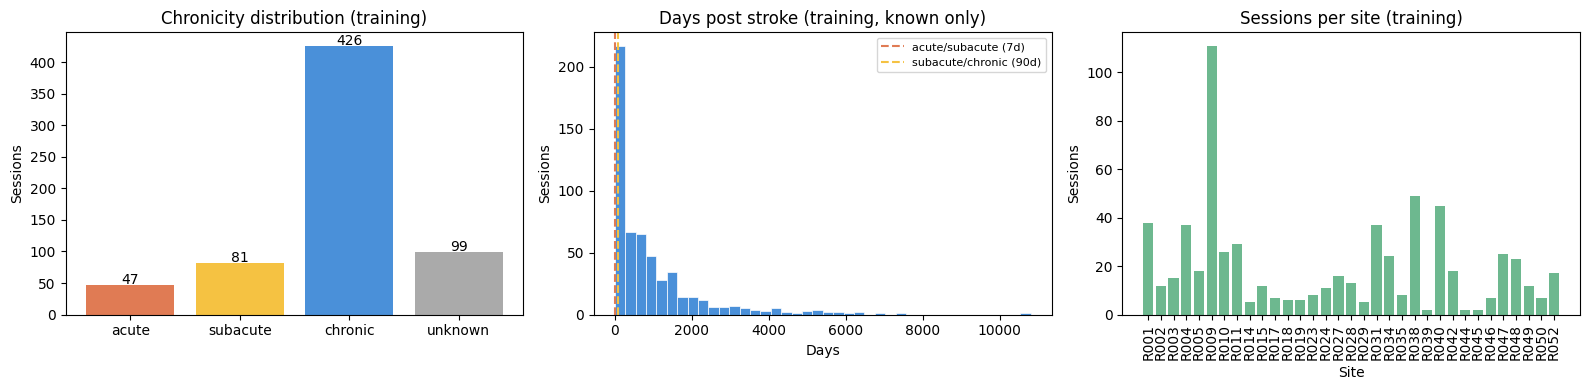


DAYS_POST_STROKE — median: 519d, mean: 957d, max: 10806d


In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# ── Plot 1: Chronicity distribution ───────────────────────────────────────────
order = ["acute", "subacute", "chronic", "unknown"]
chron_counts = df_train["CHRONICITY_DERIVED"].value_counts().reindex(order).fillna(0)
axes[0].bar(chron_counts.index, chron_counts.values,
            color=["#e07b54", "#f5c242", "#4a90d9", "#aaaaaa"])
axes[0].set_title("Chronicity distribution (training)")
axes[0].set_ylabel("Sessions")
for i, v in enumerate(chron_counts.values):
    axes[0].text(i, v + 2, str(int(v)), ha="center", fontsize=10)

# ── Plot 2: Days post stroke histogram ────────────────────────────────────────
days_valid = df_train["DAYS_POST_STROKE"].dropna()
axes[1].hist(days_valid, bins=40, color="#4a90d9", edgecolor="white", linewidth=0.5)
axes[1].axvline(7,  color="#e07b54", linestyle="--", linewidth=1.5, label="acute/subacute (7d)")
axes[1].axvline(90, color="#f5c242", linestyle="--", linewidth=1.5, label="subacute/chronic (90d)")
axes[1].set_title("Days post stroke (training, known only)")
axes[1].set_xlabel("Days")
axes[1].set_ylabel("Sessions")
axes[1].legend(fontsize=8)

# ── Plot 3: Sessions per site ─────────────────────────────────────────────────
site_counts = df_train["SITE"].value_counts().sort_index()
axes[2].bar(site_counts.index, site_counts.values, color="#6db88f")
axes[2].set_title("Sessions per site (training)")
axes[2].set_xlabel("Site")
axes[2].set_ylabel("Sessions")
axes[2].tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "eda_metadata.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"\nDAYS_POST_STROKE — median: {days_valid.median():.0f}d, "
      f"mean: {days_valid.mean():.0f}d, max: {days_valid.max():.0f}d")

## 2. Orientation and spacing audit
Samples a subset of scans (fast) to characterise orientation, voxel spacing, and image shape diversity.

In [13]:
# # ── Build training image list ─────────────────────────────────────────────────
# train_uids = set(df_train["UID"].dropna())
# all_images = sorted(IMAGES_DIR.glob("*.nii.gz"))

# # Diagnose the stem format before filtering
# sample_stems = [p.name for p in all_images[:3]]
# sample_uids  = list(train_uids)[:3]
# print(f"Sample image filenames : {sample_stems}")
# print(f"Sample UIDs from meta  : {sample_uids}")

# # Strip _T1w.nii.gz suffix to get bare UID
# def img_to_uid(p: Path) -> str:
#     return p.name.replace("_T1w.nii.gz", "")

# train_imgs  = [p for p in all_images if img_to_uid(p) in train_uids]
# sample_imgs = train_imgs[:200]

# print(f"\nAll images found       : {len(all_images)}")
# print(f"Training images matched: {len(train_imgs)}")
# print(f"Audit sample size      : {len(sample_imgs)}")

# assert len(train_imgs) > 0, \
#     f"No training images matched. Check stem format above.\n" \
#     f"Image stem example : '{img_to_uid(all_images[0])}'\n" \
#     f"UID example        : '{sample_uids[0]}'"

Sample image filenames : []
Sample UIDs from meta  : ['R023__sub-r023s001__ses-1', 'R042__sub-r042s035__ses-1', 'R004__sub-r004s002__ses-1']

All images found       : 0
Training images matched: 0
Audit sample size      : 0


IndexError: list index out of range

In [14]:
# ── Build training image list from raw tree ───────────────────────────────────
train_uids  = set(df_train["UID"].dropna())

# All T1w images in the raw tree (excludes mask files)
all_images  = sorted(DATA_ROOT.rglob("*T1w.nii.gz"))

def img_to_uid(p: Path) -> str:
    """Reconstruct UID from raw tree path: site__subject__session."""
    parts = p.relative_to(DATA_ROOT).parts  # (site, subject, session, anat, file)
    if len(parts) >= 3:
        return f"{parts[0]}__{parts[1]}__{parts[2]}"
    return ""

train_imgs  = [p for p in all_images if img_to_uid(p) in train_uids]
sample_imgs = train_imgs[:200]

print(f"All T1w files found      : {len(all_images)}")
print(f"Training images matched  : {len(train_imgs)}")
print(f"Audit sample size        : {len(sample_imgs)}")

# Spot-check UID resolution
if all_images:
    ex = all_images[0]
    print(f"\nExample path  : {ex.relative_to(DATA_ROOT)}")
    print(f"Resolved UID  : {img_to_uid(ex)}")
    print(f"In train_uids : {img_to_uid(ex) in train_uids}")

assert len(train_imgs) > 0, (
    "No training images matched. Check UID resolution above.\n"
    f"Sample all_images UID : '{img_to_uid(all_images[0]) if all_images else 'none'}'\n"
    f"Sample train_uid      : '{next(iter(train_uids)) if train_uids else 'none'}'"
)

All T1w files found      : 1453
Training images matched  : 653
Audit sample size        : 200

Example path  : R001/sub-r001s001/ses-1/anat/sub-r001s001_ses-1_space-orig_desc-brain_T1w.nii.gz
Resolved UID  : R001__sub-r001s001__ses-1
In train_uids : True


In [15]:
def load_header_stats(nii_path: Path) -> dict:
    """Extract orientation and spacing info without loading voxel data."""
    img    = nib.load(str(nii_path))
    hdr    = img.header
    affine = img.affine
    shape  = img.shape
    zooms  = hdr.get_zooms()[:3]
    ornt   = nib.orientations.aff2axcodes(affine)

    return {
        "path":        str(nii_path),
        "shape":       shape,
        "spacing_x":   round(float(zooms[0]), 3),
        "spacing_y":   round(float(zooms[1]), 3),
        "spacing_z":   round(float(zooms[2]), 3),
        "orientation": "".join(ornt),
        "n_voxels":    int(np.prod(shape)),
    }


print(f"Auditing {len(sample_imgs)} training images for orientation/spacing ...")

header_records = []
errors = []

for p in tqdm(sample_imgs):
    try:
        header_records.append(load_header_stats(p))
    except Exception as e:
        errors.append((p.name, str(e)))

# Always report errors before asserting
if errors:
    print(f"\nErrors ({len(errors)}):")
    for name, err in errors[:10]:
        print(f"  {name}: {err}")

assert len(header_records) > 0, (
    f"All {len(sample_imgs)} scans failed to load. "
    f"First error: {errors[0] if errors else 'unknown'}"
)

df_hdr = pd.DataFrame(header_records)

print(f"\nSuccessfully loaded: {len(df_hdr)} / {len(sample_imgs)}")
print(f"\nOrientation distribution:")
print(df_hdr["orientation"].value_counts())
print(f"\nVoxel spacing (mm) — x/y/z:")
for ax in ["spacing_x", "spacing_y", "spacing_z"]:
    s = df_hdr[ax]
    print(f"  {ax}: min={s.min():.2f}  median={s.median():.2f}  max={s.max():.2f}  unique={s.nunique()}")
print(f"\nImage shape diversity (unique shapes): {df_hdr['shape'].apply(str).nunique()}")

Auditing 200 training images for orientation/spacing ...


  0%|          | 0/200 [00:00<?, ?it/s]


Successfully loaded: 200 / 200

Orientation distribution:
orientation
RAS    120
LAS     80
Name: count, dtype: int64

Voxel spacing (mm) — x/y/z:
  spacing_x: min=1.00  median=1.00  max=1.10  unique=3
  spacing_y: min=1.00  median=1.00  max=1.00  unique=1
  spacing_z: min=1.00  median=1.00  max=1.00  unique=1

Image shape diversity (unique shapes): 88


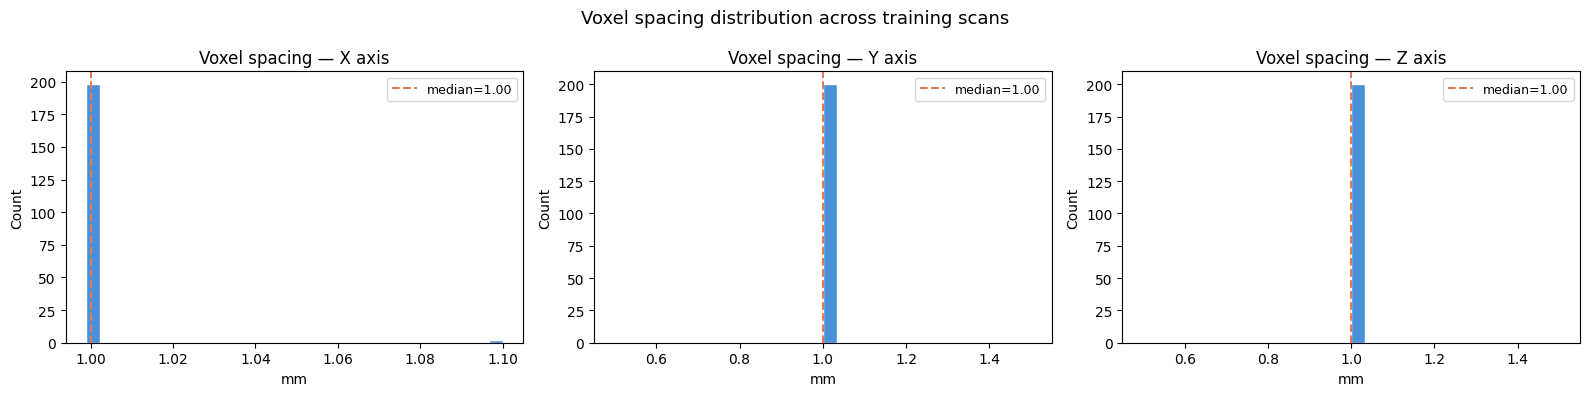

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for i, ax_name in enumerate(["spacing_x", "spacing_y", "spacing_z"]):
    axes[i].hist(df_hdr[ax_name], bins=30, color="#4a90d9", edgecolor="white")
    axes[i].set_title(f"Voxel spacing — {ax_name.split('_')[1].upper()} axis")
    axes[i].set_xlabel("mm")
    axes[i].set_ylabel("Count")
    axes[i].axvline(df_hdr[ax_name].median(), color="#e07b54",
                    linestyle="--", linewidth=1.5, label=f"median={df_hdr[ax_name].median():.2f}")
    axes[i].legend(fontsize=9)

plt.suptitle("Voxel spacing distribution across training scans", fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "eda_spacing.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Intensity audit
Loads voxel data for a sample of scans and measures per-scan intensity statistics.
This directly determines the normalisation strategy.

In [17]:
def load_intensity_stats(nii_path: Path) -> dict:
    """Compute foreground intensity statistics (brain voxels only, > 0)."""
    data = nib.load(str(nii_path)).get_fdata(dtype=np.float32)
    fg   = data[data > 0].ravel()
    if len(fg) == 0:
        return None
    return {
        "path":   str(nii_path),
        "mean":   float(np.mean(fg)),
        "std":    float(np.std(fg)),
        "p1":     float(np.percentile(fg, 1)),
        "p99":    float(np.percentile(fg, 99)),
        "median": float(np.median(fg)),
        "min":    float(fg.min()),
        "max":    float(fg.max()),
        "fg_voxels": len(fg),
    }


# Sample 100 training scans — loading voxels is slow on Kaggle
intensity_sample = train_imgs[:100]
print(f"Computing intensity stats for {len(intensity_sample)} scans ...")

intensity_records = []
for p in tqdm(intensity_sample):
    try:
        rec = load_intensity_stats(p)
        if rec:
            intensity_records.append(rec)
    except Exception as e:
        print(f"  WARN: {p.name} — {e}")

df_int = pd.DataFrame(intensity_records)

print(f"\nIntensity statistics across {len(df_int)} scans (foreground voxels):")
print(df_int[["mean", "std", "median", "p1", "p99"]].describe().round(1))

Computing intensity stats for 100 scans ...


  0%|          | 0/100 [00:00<?, ?it/s]


Intensity statistics across 100 scans (foreground voxels):
         mean     std  median     p1     p99
count   100.0   100.0   100.0  100.0   100.0
mean   1138.9   462.5  1205.2  147.6  1926.7
std    1162.1   460.5  1232.4  155.4  1928.9
min     117.1    53.1   121.0   12.0   217.0
25%     220.2    94.1   228.5   28.0   395.2
50%     332.2   137.3   350.5   46.0   563.5
75%    2374.8   989.8  2522.5  284.0  4084.5
max    3386.4  1305.1  3549.9  492.9  5333.1


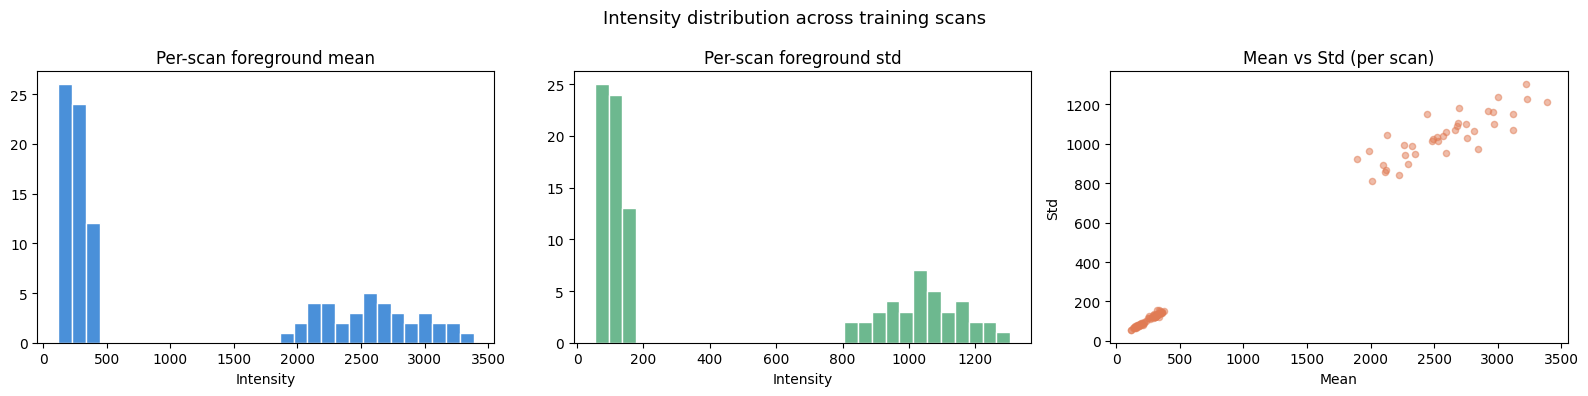


Intensity range outliers (> mean + 3σ): 0


In [18]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(df_int["mean"], bins=30, color="#4a90d9", edgecolor="white")
axes[0].set_title("Per-scan foreground mean")
axes[0].set_xlabel("Intensity")

axes[1].hist(df_int["std"], bins=30, color="#6db88f", edgecolor="white")
axes[1].set_title("Per-scan foreground std")
axes[1].set_xlabel("Intensity")

axes[2].scatter(df_int["mean"], df_int["std"], alpha=0.5, color="#e07b54", s=20)
axes[2].set_title("Mean vs Std (per scan)")
axes[2].set_xlabel("Mean")
axes[2].set_ylabel("Std")

plt.suptitle("Intensity distribution across training scans", fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "eda_intensity.png", dpi=150, bbox_inches="tight")
plt.show()

# Flag scans with extreme intensity ranges (potential outliers)
p99_range = df_int["p99"] - df_int["p1"]
outlier_thresh = p99_range.mean() + 3 * p99_range.std()
outliers = df_int[p99_range > outlier_thresh]
print(f"\nIntensity range outliers (> mean + 3σ): {len(outliers)}")
if len(outliers):
    print(outliers[["path", "mean", "std", "p1", "p99"]].to_string())

## 4. Lesion audit
Measures lesion volume, prevalence of empty masks, and size distribution.
Critical for loss weighting and augmentation design.

In [27]:
# At the top of the lesion audit cell, add this helper
def find_mask_for_image(img_path: Path) -> Path | None:
    """Find the lesion mask co-located with a T1w image."""
    parent = img_path.parent
    masks  = list(parent.glob("*label*.nii.gz")) + \
             list(parent.glob("*mask*.nii.gz"))
    # Exclude brain_mask files
    masks  = [m for m in masks if "brain_mask" not in m.name]
    return masks[0] if masks else None
    
def load_lesion_stats(img_path: Path, mask_path: Path) -> dict:
    """Compute lesion volume and voxel-level properties from mask + image pair."""
    img_nib  = nib.load(str(img_path))
    mask_nib = nib.load(str(mask_path))

    mask          = (mask_nib.get_fdata(dtype=np.float32) > 0.5).astype(np.uint8)
    zooms         = img_nib.header.get_zooms()[:3]
    voxel_vol_mm3 = float(np.prod(zooms))
    n_lesion      = int(mask.sum())
    total_voxels  = int(np.prod(mask.shape))

    return {
        "uid": img_to_uid(img_path),
        "lesion_voxels":   n_lesion,
        "lesion_vol_mm3":  n_lesion * voxel_vol_mm3,
        "lesion_vol_ml":   n_lesion * voxel_vol_mm3 / 1000,
        "total_voxels":    total_voxels,
        "lesion_fraction": n_lesion / total_voxels if total_voxels > 0 else 0,
        "is_empty":        n_lesion == 0,
    }


lesion_records     = []
errors             = []
missing_mask_count = 0

print(f"Computing lesion stats for {len(train_imgs)} training scans ...")

# Diagnose mask path construction on first scan before the loop
test_uid       = train_imgs[0].name.replace("_T1w.nii.gz", "")
test_mask_path = MASKS_DIR / f"{test_uid}_rater1.nii.gz"
print(f"\nMask path check:")
print(f"  Image name : {train_imgs[0].name}")
print(f"  Derived UID: {test_uid}")
print(f"  Mask path  : {test_mask_path}")
print(f"  Mask exists: {test_mask_path.exists()}")

# List a few actual mask filenames for comparison
actual_masks = sorted(MASKS_DIR.glob("*.nii.gz"))[:3]
print(f"  Actual mask names: {[m.name for m in actual_masks]}")

for img_path in tqdm(train_imgs):
    uid       = img_path.name.replace("_T1w.nii.gz", "")
    mask_path = find_mask_for_image(img_path)
    
    if mask_path is None:
        missing_mask_count += 1
        continue
    try:
        lesion_records.append(load_lesion_stats(img_path, mask_path))
    except Exception as e:
        errors.append((uid, str(e)))

if errors:
    print(f"\nLoad errors ({len(errors)}):")
    for uid, err in errors[:5]:
        print(f"  {uid}: {err}")

assert len(lesion_records) > 0, (
    f"No lesion records loaded.\n"
    f"  missing_mask_count={missing_mask_count}\n"
    f"  errors={len(errors)}\n"
    f"  First error: {errors[0] if errors else 'none'}"
)

df_les = pd.DataFrame(lesion_records)

print(f"\nLesion audit ({len(df_les)} scans):")
print(f"  Empty masks (no lesion)  : {df_les['is_empty'].sum()} "
      f"({df_les['is_empty'].mean()*100:.1f}%)")
print(f"  Missing mask files       : {missing_mask_count}")
print(f"\nLesion volume (mL) — non-empty only:")
non_empty = df_les[~df_les["is_empty"]]
print(non_empty["lesion_vol_ml"].describe().round(2))

Computing lesion stats for 653 training scans ...

Mask path check:
  Image name : sub-r001s001_ses-1_space-orig_desc-brain_T1w.nii.gz
  Derived UID: sub-r001s001_ses-1_space-orig_desc-brain
  Mask path  : /kaggle/temp/atlas3_raw_extracted/ATLAS3_Training_Raw/sub-r001s001_ses-1_space-orig_desc-brain_rater1.nii.gz
  Mask exists: False
  Actual mask names: []


  0%|          | 0/653 [00:00<?, ?it/s]

pixdim[1,2,3] should be positive; setting to abs of pixdim values



Lesion audit (653 scans):
  Empty masks (no lesion)  : 0 (0.0%)
  Missing mask files       : 0

Lesion volume (mL) — non-empty only:
count    653.00
mean      24.50
std       46.15
min        0.01
25%        0.90
50%        3.88
75%       26.62
max      387.63
Name: lesion_vol_ml, dtype: float64


Lesion size categories:
size_cat
large (>10 mL)      240
medium (1-10 mL)    239
small (<1 mL)       174
Name: count, dtype: int64


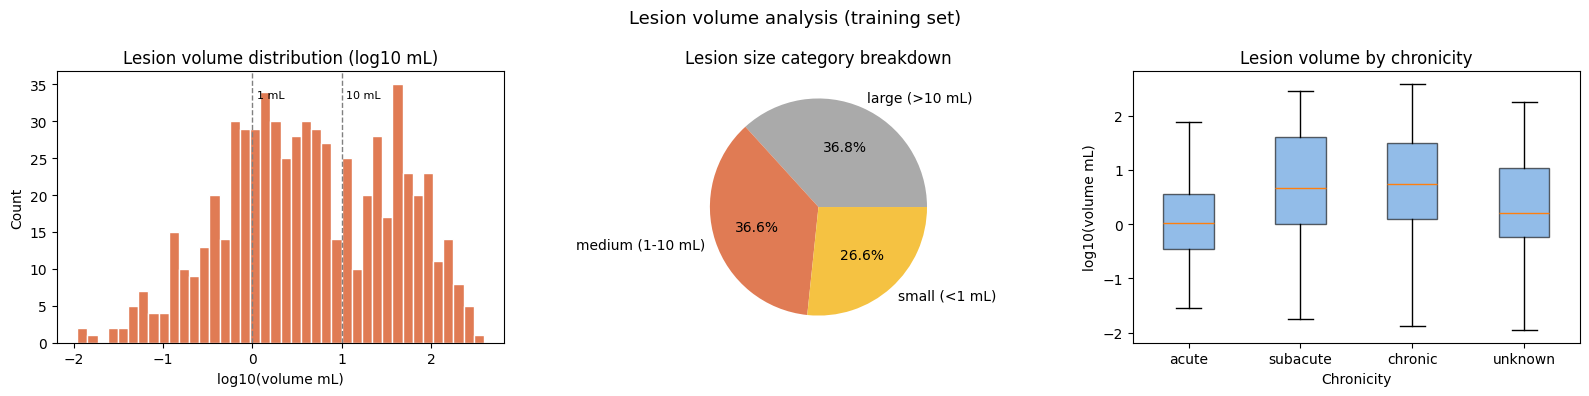

In [28]:
# Size stratification thresholds (standard in stroke literature)
# small < 1 mL, medium 1–10 mL, large > 10 mL
def size_category(vol_ml: float) -> str:
    if vol_ml == 0:   return "empty"
    if vol_ml < 1:    return "small (<1 mL)"
    if vol_ml <= 10:  return "medium (1-10 mL)"
    return "large (>10 mL)"

df_les["size_cat"] = df_les["lesion_vol_ml"].apply(size_category)
print("Lesion size categories:")
print(df_les["size_cat"].value_counts())

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# ── Plot 1: Volume histogram (log scale) ──────────────────────────────────────
vols = non_empty["lesion_vol_ml"].values
axes[0].hist(np.log10(vols + 1e-3), bins=40, color="#e07b54", edgecolor="white")
axes[0].set_title("Lesion volume distribution (log10 mL)")
axes[0].set_xlabel("log10(volume mL)")
axes[0].set_ylabel("Count")
for thresh, label in [(0, "1 mL"), (1, "10 mL")]:
    axes[0].axvline(thresh, color="grey", linestyle="--", linewidth=1)
    axes[0].text(thresh + 0.05, axes[0].get_ylim()[1]*0.9, label, fontsize=8)

# ── Plot 2: Size category pie ─────────────────────────────────────────────────
cat_counts = df_les["size_cat"].value_counts()
axes[1].pie(cat_counts.values, labels=cat_counts.index, autopct="%1.1f%%",
            colors=["#aaaaaa", "#e07b54", "#f5c242", "#4a90d9"])
axes[1].set_title("Lesion size category breakdown")

# ── Plot 3: Volume by chronicity ──────────────────────────────────────────────
df_les_meta = df_les.merge(
    df_train[["UID", "CHRONICITY_DERIVED"]].rename(columns={"UID": "uid"}),
    on="uid", how="left"
)
chron_order = ["acute", "subacute", "chronic", "unknown"]
df_les_meta_ne = df_les_meta[~df_les_meta["is_empty"]]
axes[2].boxplot(
    [np.log10(df_les_meta_ne[df_les_meta_ne["CHRONICITY_DERIVED"] == c]["lesion_vol_ml"] + 1e-3)
     for c in chron_order],
    labels=chron_order, patch_artist=True,
    boxprops=dict(facecolor="#4a90d9", alpha=0.6)
)
axes[2].set_title("Lesion volume by chronicity")
axes[2].set_ylabel("log10(volume mL)")
axes[2].set_xlabel("Chronicity")

plt.suptitle("Lesion volume analysis (training set)", fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "eda_lesion.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Site heterogeneity audit
Measures cross-site intensity and spacing variance — determines whether
site-level harmonisation is needed beyond per-scan normalisation.

In [23]:
# # Merge intensity stats with site labels
# df_int["uid"] = [Path(p).stem.replace("_T1w", "") for p in df_int["path"]]
# df_int_meta = df_int.merge(
#     df_train[["UID", "SITE", "CHRONICITY_DERIVED"]].rename(columns={"UID": "uid"}),
#     on="uid", how="left"
# )

# # Per-site mean intensity stats
# site_stats = (
#     df_int_meta.groupby("SITE")[["mean", "std"]]
#     .agg(["mean", "std"])
#     .round(1)
# )
# print("Per-site intensity statistics (mean ± std of per-scan means):")
# print(site_stats.to_string())

# # Inter-site coefficient of variation for intensity mean
# site_means = df_int_meta.groupby("SITE")["mean"].mean()
# cv_intensity = site_means.std() / site_means.mean()
# print(f"\nInter-site CV (intensity mean): {cv_intensity:.3f}")
# print("  > 0.15 → site-level harmonisation likely needed")
# print("  ≤ 0.15 → per-scan z-score normalisation likely sufficient")

In [24]:
# fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# # ── Plot 1: Per-site intensity mean boxplot ────────────────────────────────────
# sites_in_sample = sorted(df_int_meta["SITE"].dropna().unique())
# axes[0].boxplot(
#     [df_int_meta[df_int_meta["SITE"] == s]["mean"].values for s in sites_in_sample],
#     labels=sites_in_sample, patch_artist=True,
#     boxprops=dict(facecolor="#6db88f", alpha=0.6)
# )
# axes[0].set_title("Per-scan intensity mean by site")
# axes[0].set_xlabel("Site")
# axes[0].set_ylabel("Mean intensity (raw)")
# axes[0].tick_params(axis="x", rotation=90)

# # ── Plot 2: Spacing z vs site (proxy for acquisition protocol diversity) ──────
# df_hdr["uid"]  = [Path(p).stem.replace("_T1w", "") for p in df_hdr["path"]]
# df_hdr_meta = df_hdr.merge(
#     df_train[["UID", "SITE"]].rename(columns={"UID": "uid"}),
#     on="uid", how="left"
# )
# axes[1].boxplot(
#     [df_hdr_meta[df_hdr_meta["SITE"] == s]["spacing_z"].values for s in sites_in_sample],
#     labels=sites_in_sample, patch_artist=True,
#     boxprops=dict(facecolor="#f5c242", alpha=0.6)
# )
# axes[1].set_title("Z-axis voxel spacing (mm) by site")
# axes[1].set_xlabel("Site")
# axes[1].set_ylabel("Spacing Z (mm)")
# axes[1].tick_params(axis="x", rotation=90)

# plt.suptitle("Site-level heterogeneity", fontsize=13)
# plt.tight_layout()
# plt.savefig(OUTPUT_DIR / "eda_site_heterogeneity.png", dpi=150, bbox_inches="tight")
# plt.show()

Intensity → metadata merge: 100 / 100 matched

Per-site intensity statistics:
        mean            std       
        mean    std    mean    std
SITE                              
R001  2583.3  384.0  1039.8  118.5
R002   172.3   38.1    78.1   14.3
R003   186.9   38.1    82.7   14.7
R004   310.1   47.3   130.3   17.9

Inter-site CV (intensity mean): 1.453
  > 0.15 → site-level harmonisation likely needed
  ≤ 0.15 → per-scan z-score normalisation likely sufficient


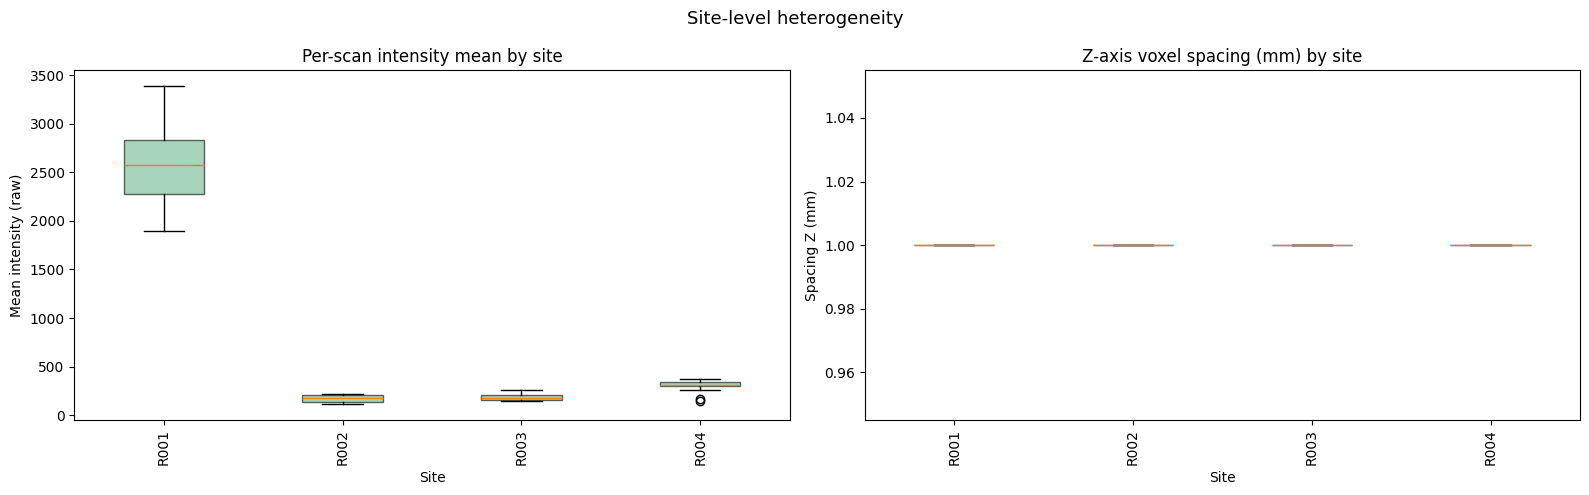

In [30]:
# ── Section 5: Site heterogeneity audit ──────────────────────────────────────

# Rebuild uid column from intensity records using consistent stripping
# Fix: strip both .nii.gz extensions correctly
df_int["uid"] = [img_to_uid(Path(p)) for p in df_int["path"]]

# Merge with training metadata
df_int_meta = df_int.merge(
    df_train[["UID", "SITE", "CHRONICITY_DERIVED"]].rename(columns={"UID": "uid"}),
    on="uid", how="left"
)

# Diagnose merge
n_matched = df_int_meta["SITE"].notna().sum()
print(f"Intensity → metadata merge: {n_matched} / {len(df_int_meta)} matched")
if n_matched == 0:
    print("  Sample intensity UIDs :", df_int["uid"].head(3).tolist())
    print("  Sample train UIDs     :", df_train["UID"].head(3).tolist())

assert n_matched > 0, "Merge failed — check UID format mismatch above"

# ── Per-site stats ────────────────────────────────────────────────────────────
site_stats = (
    df_int_meta.groupby("SITE")[["mean", "std"]]
    .agg(["mean", "std"])
    .round(1)
)
print("\nPer-site intensity statistics:")
print(site_stats.to_string())

site_means    = df_int_meta.groupby("SITE")["mean"].mean()
cv_intensity  = site_means.std() / site_means.mean()
print(f"\nInter-site CV (intensity mean): {cv_intensity:.3f}")
print("  > 0.15 → site-level harmonisation likely needed")
print("  ≤ 0.15 → per-scan z-score normalisation likely sufficient")

# ── Plots ─────────────────────────────────────────────────────────────────────
sites_in_sample = sorted(df_int_meta["SITE"].dropna().unique())
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Guard: only plot sites that have data
intensity_by_site = [df_int_meta[df_int_meta["SITE"] == s]["mean"].dropna().values
                     for s in sites_in_sample]
intensity_by_site = [(s, v) for s, v in zip(sites_in_sample, intensity_by_site) if len(v) > 0]
plot_sites  = [s for s, _ in intensity_by_site]
plot_values = [v for _, v in intensity_by_site]

axes[0].boxplot(plot_values, tick_labels=plot_sites, patch_artist=True,
                boxprops=dict(facecolor="#6db88f", alpha=0.6))
axes[0].set_title("Per-scan intensity mean by site")
axes[0].set_xlabel("Site")
axes[0].set_ylabel("Mean intensity (raw)")
axes[0].tick_params(axis="x", rotation=90)

# Spacing by site — rebuild from df_hdr
df_hdr["uid"] = [img_to_uid(Path(p)) for p in df_hdr["path"]]
df_hdr_meta   = df_hdr.merge(
    df_train[["UID", "SITE"]].rename(columns={"UID": "uid"}),
    on="uid", how="left"
)
spacing_by_site = [(s, df_hdr_meta[df_hdr_meta["SITE"] == s]["spacing_z"].dropna().values)
                   for s in plot_sites]
spacing_by_site = [(s, v) for s, v in spacing_by_site if len(v) > 0]
sp_sites  = [s for s, _ in spacing_by_site]
sp_values = [v for _, v in spacing_by_site]

axes[1].boxplot(sp_values, tick_labels=sp_sites, patch_artist=True,
                boxprops=dict(facecolor="#f5c242", alpha=0.6))
axes[1].set_title("Z-axis voxel spacing (mm) by site")
axes[1].set_xlabel("Site")
axes[1].set_ylabel("Spacing Z (mm)")
axes[1].tick_params(axis="x", rotation=90)

plt.suptitle("Site-level heterogeneity", fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "eda_site_heterogeneity.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Visual spot-check — one scan per chronicity class

IndexError: list index out of range

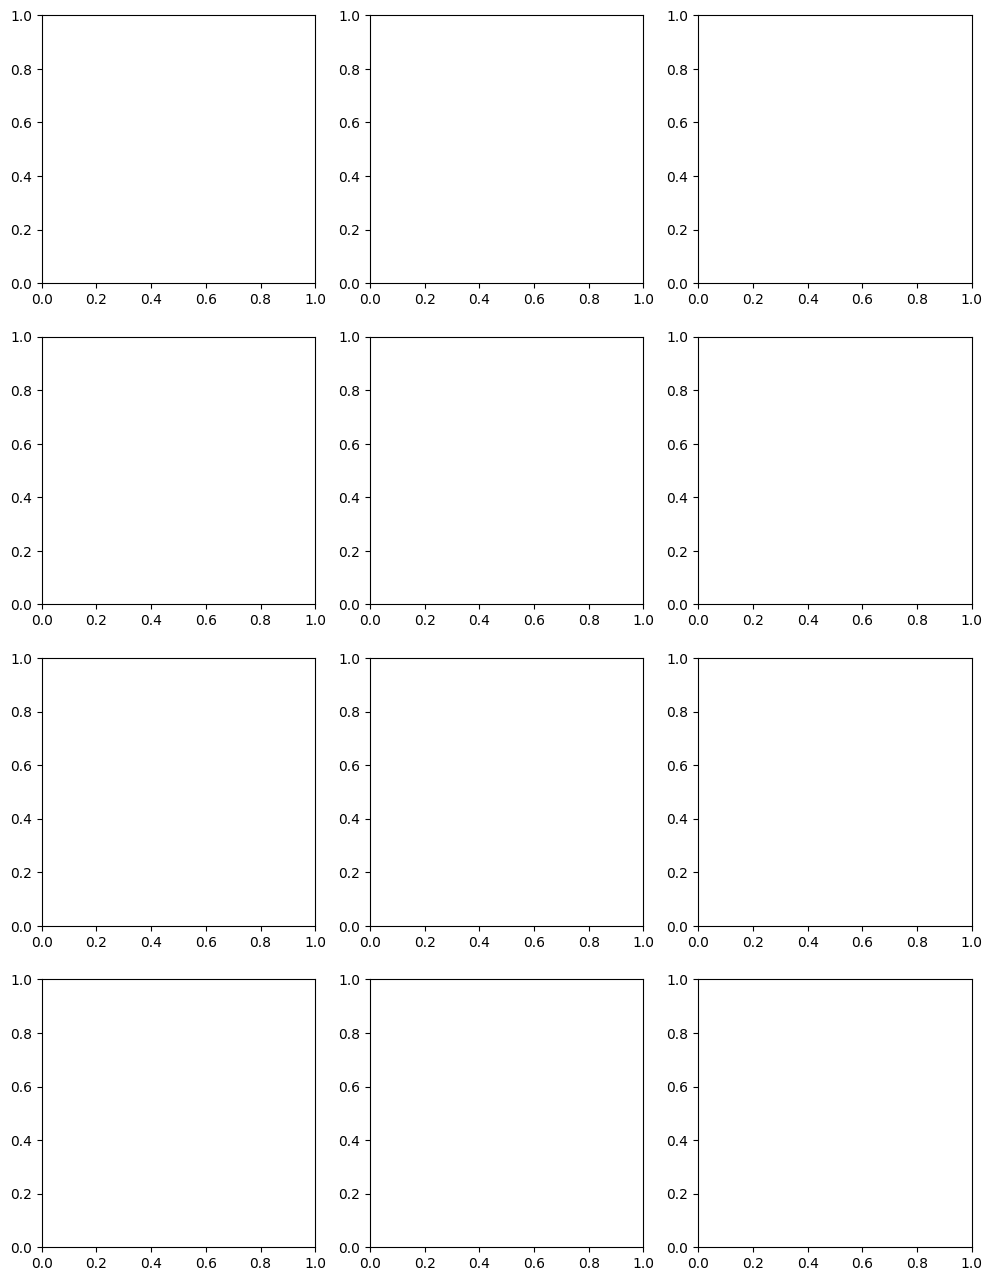

In [31]:
def show_scan_with_mask(img_path: Path, mask_path: Path,
                        title: str = "", ax_row=None) -> None:
    """Show axial/coronal/sagittal mid-slices with lesion overlay."""
    img_data  = nib.load(str(img_path)).get_fdata(dtype=np.float32)
    mask_data = nib.load(str(mask_path)).get_fdata(dtype=np.float32)

    # Normalise for display
    fg = img_data[img_data > 0]
    vmin, vmax = np.percentile(fg, 1), np.percentile(fg, 99)

    planes = [
        (img_data[img_data.shape[0]//2, :, :],  mask_data[mask_data.shape[0]//2, :, :],  "Sagittal"),
        (img_data[:, img_data.shape[1]//2, :],  mask_data[:, mask_data.shape[1]//2, :],  "Coronal"),
        (img_data[:, :, img_data.shape[2]//2],  mask_data[:, :, mask_data.shape[2]//2],  "Axial"),
    ]
    for i, (im_sl, mk_sl, plane_name) in enumerate(planes):
        ax = ax_row[i]
        ax.imshow(im_sl.T, cmap="gray", origin="lower", vmin=vmin, vmax=vmax)
        if mk_sl.max() > 0:
            ax.imshow(np.ma.masked_where(mk_sl.T == 0, mk_sl.T),
                      cmap="Reds", alpha=0.5, origin="lower")
        ax.set_title(f"{title}\n{plane_name}", fontsize=8)
        ax.axis("off")


# Pick one representative scan per chronicity class
fig, axes = plt.subplots(4, 3, figsize=(12, 16))
shown = 0
for chron in ["acute", "subacute", "chronic", "unknown"]:
    subset = df_les_meta[
        (df_les_meta["CHRONICITY_DERIVED"] == chron) &
        (~df_les_meta["is_empty"])
    ]
    if len(subset) == 0:
        continue
    # Pick the median-volume scan for representativeness
    med_idx = (subset["lesion_vol_ml"] - subset["lesion_vol_ml"].median()).abs().idxmin()
    img_matches  = list(DATA_ROOT.rglob(f"*{uid.split('__')[1]}*T1w.nii.gz"))
    mask_matches = list(DATA_ROOT.rglob(f"*{uid.split('__')[1]}*label*.nii.gz"))
    mask_matches += list(DATA_ROOT.rglob(f"*{uid.split('__')[1]}*mask*.nii.gz"))
    mask_matches  = [m for m in mask_matches if "brain_mask" not in m.name]

if img_matches and mask_matches:
    img_p  = img_matches[0]
    mask_p = mask_matches[0]
    img_p   = IMAGES_DIR / f"{uid}_T1w.nii.gz"
    mask_p  = MASKS_DIR  / f"{uid}_rater1.nii.gz"

    if img_p.exists() and mask_p.exists():
        vol = subset.loc[med_idx, "lesion_vol_ml"]
        show_scan_with_mask(img_p, mask_p,
                            title=f"{chron} | {vol:.1f} mL",
                            ax_row=axes[shown])
        shown += 1

plt.suptitle("Representative scan per chronicity class (median lesion volume)",
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "eda_visual_spotcheck.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. EDA summary export
Serialises all key findings to `eda_summary.json`.
This file will be read by `config.yaml` and the preprocessing pipeline.

In [32]:
non_empty_vols = df_les[~df_les["is_empty"]]["lesion_vol_ml"]

eda_summary = {
    "dataset": {
        "total_sessions":    1453,
        "training_sessions": int(len(df_train)),
        "testing_sessions":  int(len(df[df["ATLAS2_DATASET"] == "Testing"])),
        "n_sites":           int(df_train["SITE"].nunique()),
    },
    "chronicity": df_train["CHRONICITY_DERIVED"].value_counts().to_dict(),
    "days_post_stroke": {
        "n_known":  int(df_train["DAYS_POST_STROKE"].notna().sum()),
        "n_unknown": int(df_train["DAYS_POST_STROKE"].isna().sum()),
        "median":   float(df_train["DAYS_POST_STROKE"].median()),
        "mean":     float(df_train["DAYS_POST_STROKE"].mean()),
        "max":      float(df_train["DAYS_POST_STROKE"].max()),
    },
    "orientation": df_hdr["orientation"].value_counts().to_dict(),
    "spacing": {
        ax: {
            "min":    float(df_hdr[ax].min()),
            "median": float(df_hdr[ax].median()),
            "max":    float(df_hdr[ax].max()),
        }
        for ax in ["spacing_x", "spacing_y", "spacing_z"]
    },
    "intensity": {
        "mean_of_means":  float(df_int["mean"].mean()),
        "std_of_means":   float(df_int["mean"].std()),
        "inter_site_cv":  float(cv_intensity),
        "recommendation": "per_scan_zscore" if cv_intensity <= 0.15 else "site_harmonisation",
    },
    "lesions": {
        "empty_mask_count":    int(df_les["is_empty"].sum()),
        "empty_mask_fraction": float(df_les["is_empty"].mean()),
        "vol_ml_median":       float(non_empty_vols.median()),
        "vol_ml_mean":         float(non_empty_vols.mean()),
        "vol_ml_p10":          float(np.percentile(non_empty_vols, 10)),
        "vol_ml_p90":          float(np.percentile(non_empty_vols, 90)),
        "size_categories":     df_les["size_cat"].value_counts().to_dict(),
        "small_lesion_fraction": float((df_les["size_cat"] == "small (<1 mL)").mean()),
    },
}

summary_path = OUTPUT_DIR / "eda_summary.json"
with open(summary_path, "w") as f:
    json.dump(eda_summary, f, indent=2)

print(f"EDA summary saved: {summary_path}")
print(json.dumps(eda_summary, indent=2))

EDA summary saved: /kaggle/working/eda_summary.json
{
  "dataset": {
    "total_sessions": 955,
    "training_sessions": 653,
    "testing_sessions": 299,
    "n_sites": 33
  },
  "chronicity": {
    "chronic": 426,
    "unknown": 99,
    "subacute": 81,
    "acute": 47
  },
  "days_post_stroke": {
    "n_known": 554,
    "n_unknown": 99,
    "median": 519.0,
    "mean": 957.0270758122743,
    "max": 10806.0
  },
  "orientation": {
    "RAS": 120,
    "LAS": 80
  },
  "spacing": {
    "spacing_x": {
      "min": 0.999,
      "median": 1.0,
      "max": 1.1
    },
    "spacing_y": {
      "min": 1.0,
      "median": 1.0,
      "max": 1.0
    },
    "spacing_z": {
      "min": 1.0,
      "median": 1.0,
      "max": 1.0
    }
  },
  "intensity": {
    "mean_of_means": 1138.9184440612794,
    "std_of_means": 1162.0643726155433,
    "inter_site_cv": 1.453186290133783,
    "recommendation": "site_harmonisation"
  },
  "lesions": {
    "empty_mask_count": 0,
    "empty_mask_fraction": 0.0,
  

In [33]:
import zipfile
import os
from pathlib import Path
from IPython.display import FileLink, display

WORKING_DIR = Path("/kaggle/working")
ZIP_PATH    = WORKING_DIR / "isles26_eda_outputs.zip"

# Files to include — all artefacts produced by the EDA notebook
include_patterns = [
    "eda_metadata.png",
    "eda_spacing.png",
    "eda_intensity.png",
    "eda_lesion.png",
    "eda_site_heterogeneity.png",
    "eda_visual_spotcheck.png",
    "eda_summary.json",
]

print("Zipping EDA outputs ...")
with zipfile.ZipFile(ZIP_PATH, "w", zipfile.ZIP_DEFLATED) as zf:
    for pattern in include_patterns:
        matches = list(WORKING_DIR.glob(pattern))
        if not matches:
            print(f"  WARN: no file matched '{pattern}' — skipping")
            continue
        for f in matches:
            zf.write(f, arcname=f.name)
            print(f"  + {f.name}  ({f.stat().st_size / 1e3:.1f} KB)")

size_mb = ZIP_PATH.stat().st_size / 1e6
print(f"\nZip created: {ZIP_PATH.name}  ({size_mb:.2f} MB)")
print("Click the link below to download:\n")
display(FileLink(str(ZIP_PATH.relative_to(WORKING_DIR)), result_html_prefix="⬇ Download: "))

Zipping EDA outputs ...
  + eda_metadata.png  (84.2 KB)
  + eda_spacing.png  (52.4 KB)
  + eda_intensity.png  (67.2 KB)
  + eda_lesion.png  (91.2 KB)
  + eda_site_heterogeneity.png  (63.4 KB)
  + eda_visual_spotcheck.png  (75.7 KB)
  + eda_summary.json  (1.3 KB)

Zip created: isles26_eda_outputs.zip  (0.34 MB)
Click the link below to download:



/kaggle/working/isles26_eda_outputs.zip

In [34]:
# import json, os, subprocess
# from pathlib import Path

# USERNAME = "josephderrick"
# SLUG     = "isles26-atlas-v3-raw"

# # ── Find what to commit ───────────────────────────────────────────────────────
# # Priority: organised atlas_raw > EDA outputs folder
# CANDIDATES = [
#     Path("/kaggle/working/atlas_raw"),          # from ingestion notebook
#     Path("/kaggle/working"),                    # fallback: all working outputs
# ]
# COMMIT_DIR = next((p for p in CANDIDATES if p.exists() and any(p.iterdir())), None)
# assert COMMIT_DIR is not None, "No non-empty directory found to commit."
# print(f"Committing from: {COMMIT_DIR}")
# print(f"Contents: {[p.name for p in COMMIT_DIR.iterdir()]}")

# # ── Write dataset metadata ────────────────────────────────────────────────────
# meta = {
#     "title":    "ISLES26 ATLAS v3 Raw Organised",
#     "id":       f"{USERNAME}/{SLUG}",
#     "licenses": [{"name": "other"}],
# }
# meta_file = COMMIT_DIR / "dataset-metadata.json"
# with open(meta_file, "w") as f:
#     json.dump(meta, f)
# print(f"Metadata written: {meta_file}")

# # ── Push to Kaggle ────────────────────────────────────────────────────────────
# # Try create first; if dataset exists, version it instead
# for cmd in [
#     ["kaggle", "datasets", "create", "-p", str(COMMIT_DIR), "--dir-mode", "zip"],
#     ["kaggle", "datasets", "version", "-p", str(COMMIT_DIR), "-m", "v3 full dataset 1453 sessions"],
# ]:
#     result = subprocess.run(cmd, capture_output=True, text=True)
#     output = result.stdout or result.stderr
#     print(output)
#     if result.returncode == 0:
#         break
#     if "already exists" in output.lower() or "403" in output:
#         print("Dataset exists — trying version update...")
#         continue
#     print(f"Command failed: {' '.join(cmd)}")
#     break

# print(f"\nDownload on RTX with:")
# print(f"  kaggle datasets download {USERNAME}/{SLUG} --path ~/isles26/data/raw --unzip")

Committing from: /kaggle/working
Contents: ['eda_spacing.png', 'eda_metadata.png', 'eda_summary.json', 'eda_visual_spotcheck.png', 'eda_site_heterogeneity.png', 'isles26_eda_outputs.zip', '.virtual_documents', 'eda_lesion.png', 'eda_intensity.png']
Metadata written: /kaggle/working/dataset-metadata.json
Starting upload for file eda_spacing.png
Upload successful: eda_spacing.png (51KB)
Starting upload for file eda_metadata.png
Upload successful: eda_metadata.png (82KB)
Starting upload for file eda_summary.json
Upload successful: eda_summary.json (1KB)
Starting upload for file eda_visual_spotcheck.png
Upload successful: eda_visual_spotcheck.png (74KB)
Starting upload for file eda_site_heterogeneity.png
Upload successful: eda_site_heterogeneity.png (62KB)
Starting upload for file isles26_eda_outputs.zip
Upload successful: isles26_eda_outputs.zip (334KB)
Starting upload for file .virtual_documents.zip
Upload successful: .virtual_documents.zip (9KB)
Starting upload for file eda_lesion.png
U

In [36]:
# import json, subprocess, shutil
# from pathlib import Path

# USERNAME   = "josephderrick"
# SLUG       = "isles26-atlas-v3-archive"
# ARCHIVE_SRC = Path("/kaggle/input/notebooks/josephderrick/fork-of-ingest-atlas-for-v3-raw/ATLAS_R3_raw.tar.gz")
# STAGE_DIR   = Path("/kaggle/working/atlas_v3_stage")
# STAGE_DIR.mkdir(exist_ok=True)

# # Stage the archive — symlink won't work, must copy
# # Check size first
# size_gb = ARCHIVE_SRC.stat().st_size / 1e9
# print(f"Archive size: {size_gb:.2f} GB")
# assert size_gb < 20, "Too large for Kaggle dataset — use Option 1 instead"

# print("Copying archive to staging dir...")
# shutil.copy2(ARCHIVE_SRC, STAGE_DIR / ARCHIVE_SRC.name)

# # Write metadata
# meta = {
#     "title":    "ISLES26 ATLAS v3 Raw Archive",
#     "id":       f"{USERNAME}/{SLUG}",
#     "licenses": [{"name": "other"}],
# }
# with open(STAGE_DIR / "dataset-metadata.json", "w") as f:
#     json.dump(meta, f)

# # Commit
# result = subprocess.run(
#     ["kaggle", "datasets", "create", "-p", str(STAGE_DIR), "--dir-mode", "zip"],
#     capture_output=True, text=True
# )
# print(result.stdout or result.stderr)

# print(f"\nThen on RTX:")
# print(f"  kaggle datasets download {USERNAME}/{SLUG} --path ~/isles26/data/raw --unzip")
# print(f"  cd ~/isles26/data/raw && tar -xf ATLAS_R3_raw.tar.gz")

Archive size: 6.09 GB
Copying archive to staging dir...
Starting upload for file ATLAS_R3_raw.tar.gz
Upload successful: ATLAS_R3_raw.tar.gz (6GB)
Your private Dataset is being created. Please check progress at https://www.kaggle.com/datasets/josephderrick/isles26-atlas-v3-archive


Then on RTX:
  kaggle datasets download josephderrick/isles26-atlas-v3-archive --path ~/isles26/data/raw --unzip
  cd ~/isles26/data/raw && tar -xf ATLAS_R3_raw.tar.gz


In [38]:
# import subprocess
# from pathlib import Path

# # 1. Install rclone
# subprocess.run("curl https://rclone.org/install.sh | sudo bash", shell=True)

# # 2. Create the rclone config directory structure
# CONFIG_DIR = Path("/root/.config/rclone")
# CONFIG_DIR.mkdir(parents=True, exist_ok=True)

# # 3. Ensure Service Account file exists
# SA_PATH = Path("/kaggle/working/sa.json")
# if not SA_PATH.exists():
#     print(
#         f"⚠️ Warning: {SA_PATH} not found. Make sure sa.json is uploaded to /kaggle/working!"
#     )

# # 4. Write rclone configuration
# RCLONE_CONF = f"""
# [gdrive]
# type = drive
# scope = drive
# service_account_file = {SA_PATH}
# """

# (CONFIG_DIR / "rclone.conf").write_text(RCLONE_CONF.strip())
# print("✅ Rclone configuration created.")

# # 5. Dynamically resolve input archive path
# ARCHIVE_PATH = Path(
#     "/kaggle/input/notebooks/josephderrick/fork-of-ingest-atlas-for-v3-raw/ATLAS_R3_raw.tar.gz"
# )
# if not ARCHIVE_PATH.exists():
#     matches = list(Path("/kaggle/input").rglob("ATLAS_R3_raw.tar.gz"))
#     if matches:
#         ARCHIVE_PATH = matches[0]

# print(f"Uploading {ARCHIVE_PATH} to GDrive (gdrive:isles26/)...")

# # 6. Upload archive to Google Drive with live progress
# subprocess.run(
#     [
#         "rclone",
#         "copy",
#         str(ARCHIVE_PATH),
#         "gdrive:isles26/",
#         "--progress",
#         "--transfers",
#         "1",
#         "--drive-chunk-size",
#         "256M",
#     ]
# )

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  4734  100  4734    0     0  11247      0 --:--:-- --:--:-- --:--:-- 11244



The latest version of rclone rclone v1.75.0 is already installed.

⚠️ Warning: /kaggle/working/sa.json not found. Make sure sa.json is uploaded to /kaggle/working!
✅ Rclone configuration created.
Uploading /kaggle/input/notebooks/josephderrick/fork-of-ingest-atlas-for-v3-raw/ATLAS_R3_raw.tar.gz to GDrive (gdrive:isles26/)...


2026/08/06 19:26:29 CRITICAL: Failed to create file system for "gdrive:isles26/": drive: failed when making oauth client: error opening service account credentials file: open /kaggle/working/sa.json: no such file or directory


CompletedProcess(args=['rclone', 'copy', '/kaggle/input/notebooks/josephderrick/fork-of-ingest-atlas-for-v3-raw/ATLAS_R3_raw.tar.gz', 'gdrive:isles26/', '--progress', '--transfers', '1', '--drive-chunk-size', '256M'], returncode=1)

In [40]:
# import json
# import os
# import shutil
# from pathlib import Path
# from kaggle.api.kaggle_api_extended import KaggleApi

# # 1. Authenticate Kaggle API
# api = KaggleApi()
# api.authenticate()

# # 2. Define Kaggle Username and Dataset ID
# username = "josephderrick"
# dataset_slug = "atlas-v3-raw-decrypted"
# dataset_id = f"{username}/{dataset_slug}"

# # 3. Create staging folder in high-capacity /kaggle/temp (~100GB available)
# staging_dir = Path("/kaggle/temp/dataset_upload_staging")
# staging_dir.mkdir(parents=True, exist_ok=True)

# # 4. Locate the tar.gz archive
# ARCHIVE_PATH = Path(
#     "/kaggle/input/notebooks/josephderrick/fork-of-ingest-atlas-for-v3-raw/ATLAS_R3_raw.tar.gz"
# )
# if not ARCHIVE_PATH.exists():
#     matches = list(Path("/kaggle/input").rglob("ATLAS_R3_raw.tar.gz"))
#     if matches:
#         ARCHIVE_PATH = matches[0]
#     else:
#         raise FileNotFoundError(
#             "Could not locate ATLAS_R3_raw.tar.gz inside /kaggle/input"
#         )

# # Stage file in upload folder
# target_file = staging_dir / ARCHIVE_PATH.name
# if not target_file.exists():
#     print(f"Staging archive in {staging_dir}...")
#     shutil.copyfile(ARCHIVE_PATH, target_file)

# # 5. Generate dataset-metadata.json
# metadata = {
#     "title": "ATLAS v3.0 Raw Decrypted",
#     "id": dataset_id,
#     "licenses": [{"name": "CC0-1.0"}],
# }
# with open(staging_dir / "dataset-metadata.json", "w") as f:
#     json.dump(metadata, f, indent=2)

# # 6. Upload to Kaggle Datasets (Creates private dataset)
# print(f"Uploading dataset to Kaggle as '{dataset_id}'...")
# api.dataset_create_new(
#     folder=str(staging_dir), dir_mode="zip", convert_to_csv=False
# )
# print(
#     f"✅ Success! Dataset created at: https://www.kaggle.com/datasets/{dataset_id}"
# )

Staging archive in /kaggle/temp/dataset_upload_staging...
Uploading dataset to Kaggle as 'josephderrick/atlas-v3-raw-decrypted'...
Starting upload for file ATLAS_R3_raw.tar.gz


100%|██████████| 5.67G/5.67G [01:05<00:00, 92.3MB/s]


Upload successful: ATLAS_R3_raw.tar.gz (6GB)
✅ Success! Dataset created at: https://www.kaggle.com/datasets/josephderrick/atlas-v3-raw-decrypted


In [42]:
!pip install kaggle

In [44]:
import json
import shutil
import subprocess
from pathlib import Path
from kaggle.api.kaggle_api_extended import KaggleApi

# 1. Authenticate API
api = KaggleApi()
api.authenticate()

username = "josephderrick"
dataset_slug = "atlas-v3-raw-decrypted"
dataset_id = f"{username}/{dataset_slug}"

# 2. Setup Staging Directory
staging_dir = Path("/kaggle/temp/dataset_upload_staging")
if staging_dir.exists():
    shutil.rmtree(staging_dir)
staging_dir.mkdir(parents=True, exist_ok=True)

# 3. Locate & Split Archive
ARCHIVE_PATH = Path(
    "/kaggle/input/notebooks/josephderrick/fork-of-ingest-atlas-for-v3-raw/ATLAS_R3_raw.tar.gz"
)
if not ARCHIVE_PATH.exists():
    ARCHIVE_PATH = list(Path("/kaggle/input").rglob("ATLAS_R3_raw.tar.gz"))[0]

print("Splitting archive into 1GB parts...")
split_prefix = str(staging_dir / "ATLAS_R3_raw.tar.gz.part_")
subprocess.run(["split", "-b", "1000M", str(ARCHIVE_PATH), split_prefix], check=True)

# 4. Generate metadata
metadata = {
    "title": "ATLAS v3.0 Raw Decrypted",
    "id": dataset_id,
    "licenses": [{"name": "CC0-1.0"}],
}
with open(staging_dir / "dataset-metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

# 5. Smart Push (New Version vs New Dataset)
print(f"Pushing to Kaggle dataset '{dataset_id}'...")
try:
    # Attempt to create a new version first if dataset exists
    api.dataset_create_version(
        folder=str(staging_dir),
        version_notes="Upload 1GB split parts",
        dir_mode="tar",
        convert_to_csv=False,
    )
    print("✅ Successfully updated existing Kaggle dataset with a new version!")
except Exception as e:
    # Fallback to creating a new dataset if it doesn't exist
    print("Creating new dataset...")
    api.dataset_create_new(
        folder=str(staging_dir), dir_mode="tar", convert_to_csv=False
    )
    print("✅ Successfully created new Kaggle dataset!")

Splitting archive into 1GB parts...
Pushing to Kaggle dataset 'josephderrick/atlas-v3-raw-decrypted'...
Starting upload for file ATLAS_R3_raw.tar.gz.part_ac


100%|██████████| 0.98G/0.98G [00:11<00:00, 88.4MB/s]


Upload successful: ATLAS_R3_raw.tar.gz.part_ac (1000MB)
Starting upload for file ATLAS_R3_raw.tar.gz.part_ad


100%|██████████| 0.98G/0.98G [00:10<00:00, 102MB/s] 


Upload successful: ATLAS_R3_raw.tar.gz.part_ad (1000MB)
Starting upload for file ATLAS_R3_raw.tar.gz.part_ab


...

100%|██████████| 806M/806M [00:06<00:00, 121MB/s]  


Upload successful: ATLAS_R3_raw.tar.gz.part_af (806MB)
Starting upload for file ATLAS_R3_raw.tar.gz.part_aa


100%|██████████| 0.98G/0.98G [00:08<00:00, 126MB/s] 


Upload successful: ATLAS_R3_raw.tar.gz.part_aa (1000MB)


KeyboardInterrupt: 